Sample of the dataset:
   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2

Dataset shape:
(300, 3)

Accuracy: 0.8333333333333334

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       0.75      0.43      0.55        14
           2       0.70      0.90      0.79        21

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.78        60
weighted avg       0.84      0.83      0.82        60


Saved tree image.


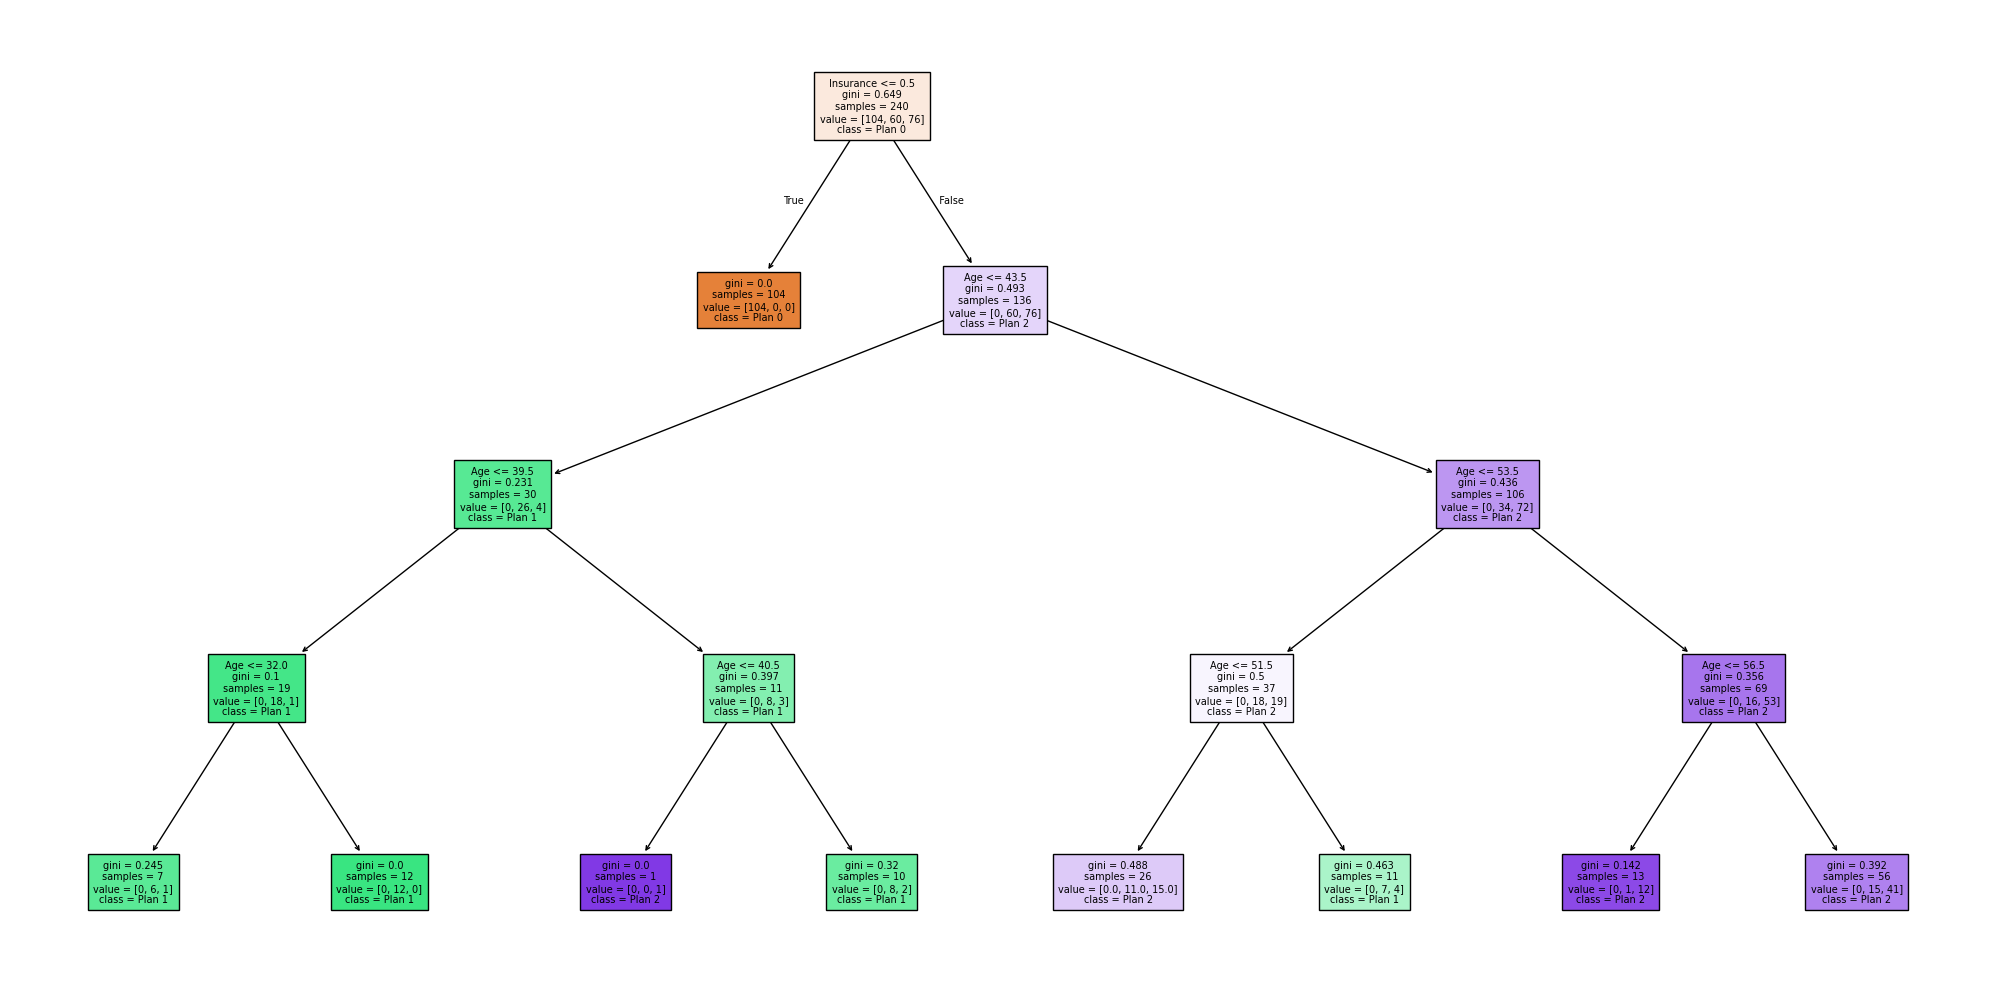

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("age_insurance (1).csv")


# Display dataset
print("Sample of the dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)


# Features and target
X = df[["Age", "Insurance"]]
y = df["InsurancePlan"]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Create Decision Tree
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)


# Train
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Accuracy
print("\nAccuracy:", accuracy_score(y_test, y_pred))


# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Plot Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Plan 0", "Plan 1", "Plan 2"],
    filled=True,
    fontsize=7
)

plt.tight_layout()

plt.savefig("decision_tree.png", dpi=150)

print("\nSaved tree image.")

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Random state
RANDOM_STATE = 42


# Load dataset
df = pd.read_csv("age_insurance (1).csv")


# Display dataset
print("Sample of the dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nClass balance:")
print(df["InsurancePlan"].value_counts())


# Target and columns to remove
TARGET = "InsurancePlan"


# Select features
feature_names = [
    c for c in df.columns
    if c != TARGET
]


X = df[feature_names].values
y = df[TARGET].values


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)


# Create Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE
)


# Train model
rf.fit(X_train, y_train)


# Prediction
y_pred = rf.predict(X_test)


# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)


# Results
print("\nOOB score:", rf.oob_score_)

print("Test accuracy:", test_accuracy)


# Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred))


# Feature importance
print("Feature importances:")

for name, importance in sorted(
    zip(feature_names, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"  {name}: {importance:.4f}")

Sample of the dataset:
   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2

Dataset shape:
(300, 3)

Class balance:
InsurancePlan
0    129
2     97
1     74
Name: count, dtype: int64

OOB score: 0.775
Test accuracy: 0.8333333333333334

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       0.67      0.57      0.62        14
           2       0.74      0.81      0.77        21

    accuracy                           0.83        60
   macro avg       0.80      0.79      0.80        60
weighted avg       0.83      0.83      0.83        60

Feature importances:
  Insurance: 0.5638
  Age: 0.4362
